In [2]:
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Configurazione PATH Miniconda
if not os.path.exists("/usr/local/miniconda"):
    print(" Configuration of the Conda environment for the first time...")
    !wget -q https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O /tmp/miniconda.sh
    !bash /tmp/miniconda.sh -b -p /usr/local/miniconda
    os.environ["PATH"] = "/usr/local/miniconda/bin:" + os.environ["PATH"]

    !conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
    !conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r
    
    !conda create -n openmmlab python=3.10 -y
    !conda run -n openmmlab pip install "numpy<2" torch==2.0.1 torchvision==0.15.2 --index-url https://download.pytorch.org/whl/cu118
    !conda run -n openmmlab pip install -U openmim
    !conda run -n openmmlab mim install mmengine "mmcv>=2.0.0rc4,<2.1.0" "mmdet>=3.0.0,<3.1.0"
    
    if not os.path.exists('/content/mmdetection3d'):
        !git clone https://github.com/open-mmlab/mmdetection3d.git -b dev-1.x /content/mmdetection3d
        %cd /content/mmdetection3d
        !conda run -n openmmlab pip install --no-build-isolation .
        %cd /content
    !conda run -n openmmlab pip install "numpy<2"
else:
    os.environ["PATH"] = "/usr/local/miniconda/bin:" + os.environ["PATH"]
    print(" Conda environment is already ready!")
    
    print(" Conda environment and OpenMMLab are active!")

Mounted at /content/drive
 Configuration of the Conda environment for the first time...
PREFIX=/usr/local/miniconda
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible with the Python interpreter
    in Miniconda3: /usr/local/miniconda
accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r
Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.7.1


In [21]:
%cd /content
if not os.path.exists('/content/3D_Perception'):
    !git clone https://github.com/giacomosalvatori03/3D_Perception.git
%cd /content/3D_Perception
!git pull

/content
/content/3D_Perception
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 547 bytes | 273.00 KiB/s, done.
From https://github.com/giacomosalvatori03/3D_Perception
   e2f2719..7366e65  main       -> origin/main
Updating e2f2719..7366e65
Fast-forward
 src/__init__.py | 16 ++++++++++------
 1 file changed, 10 insertions(+), 6 deletions(-)


In [6]:
%%bash
source /usr/local/miniconda/bin/activate openmmlab

cd /content/3D_Perception
git pull

python -u validate_lidar.py --subsample_mode none --max_samples 500

Already up to date.
 Loading PointPillars on cuda:0
Loads checkpoint by local backend from path: /content/3D_Perception/weights/pointpillar_kitti.pth
 Classes mapping extracted from the model: ['Pedestrian', 'Cyclist', 'Car']

 Starting PointPillars Inference [BASELINE_100PERC] | Samples: 500/3769
 Destination for .txt files on Drive: /content/drive/MyDrive/3D_Perception/experiments/baseline_100perc

 Inference and saving completed successfully!
  • Predictions saved in: /content/drive/MyDrive/3D_Perception/experiments/baseline_100perc/pred_labels
  • Ground Truth saved in: /content/drive/MyDrive/3D_Perception/experiments/baseline_100perc/gt_labels


/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/mmdet3d/models/dense_heads/anchor3d_head.py:94: UserWarning: dir_offset and dir_limit_offset will be depressed and be incorporated into box coder in the future
  warnings.warn(
Processing Frames:   0%|          | 0/500 [00:00<?, ?it/s]/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Processing Frames: 100%|██████████| 500/500 [07:42<00:00,  1.08it/s]


In [7]:
import sys

sys.path.insert(0, "/content/3D_Perception")
from scripts.lidar_evaluator import KittiEvaluator

evaluator = KittiEvaluator()
exp_path = (
    "/content/drive/MyDrive/3D_Perception/experiments/baseline_100perc"
)

results = evaluator.evaluate(exp_path)


 3D DETECTION mAP40 RESULTS [baseline_100perc]



,Easy,Moderate,Hard
Class,,,
Car,67.40%,62.71%,59.77%
Pedestrian,53.82%,49.63%,44.13%
Cyclist,48.11%,43.70%,42.59%



 Reports successfully saved in '/content/drive/MyDrive/3D_Perception/experiments/baseline_100perc': .json, .csv, .md, .tex


In [9]:
%%bash
source /usr/local/miniconda/bin/activate openmmlab

cd /content/3D_Perception
git pull

python -u validate_lidar.py --subsample_mode random --subsample_ratio 0.75 --max_samples 500

Already up to date.
 Loading PointPillars on cuda:0
Loads checkpoint by local backend from path: /content/3D_Perception/weights/pointpillar_kitti.pth
 Classes mapping extracted from the model: ['Pedestrian', 'Cyclist', 'Car']

 Starting PointPillars Inference [RANDOM_75PERC] | Samples: 500/3769
 Destination for .txt files on Drive: /content/drive/MyDrive/3D_Perception/experiments/random_75perc

 Inference and saving completed successfully!
  • Predictions saved in: /content/drive/MyDrive/3D_Perception/experiments/random_75perc/pred_labels
  • Ground Truth saved in: /content/drive/MyDrive/3D_Perception/experiments/random_75perc/gt_labels


/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/mmdet3d/models/dense_heads/anchor3d_head.py:94: UserWarning: dir_offset and dir_limit_offset will be depressed and be incorporated into box coder in the future
  warnings.warn(
Processing Frames:   0%|          | 0/500 [00:00<?, ?it/s]/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Processing Frames: 100%|██████████| 500/500 [00:30<00:00, 16.15it/s]


In [10]:
import sys

sys.path.insert(0, "/content/3D_Perception")
from scripts.lidar_evaluator import KittiEvaluator

evaluator = KittiEvaluator()
exp_path = (
    "/content/drive/MyDrive/3D_Perception/experiments/random_75perc"
)

results = evaluator.evaluate(exp_path)


 3D DETECTION mAP40 RESULTS [random_75perc]



,Easy,Moderate,Hard
Class,,,
Car,67.31%,59.99%,57.16%
Pedestrian,54.86%,49.82%,45.12%
Cyclist,60.29%,45.11%,46.20%



 Reports successfully saved in '/content/drive/MyDrive/3D_Perception/experiments/random_75perc': .json, .csv, .md, .tex


In [11]:
%%bash
source /usr/local/miniconda/bin/activate openmmlab

cd /content/3D_Perception
git pull

python -u validate_lidar.py --subsample_mode random --subsample_ratio 0.50 --max_samples 500

Already up to date.
 Loading PointPillars on cuda:0
Loads checkpoint by local backend from path: /content/3D_Perception/weights/pointpillar_kitti.pth
 Classes mapping extracted from the model: ['Pedestrian', 'Cyclist', 'Car']

 Starting PointPillars Inference [RANDOM_50PERC] | Samples: 500/3769
 Destination for .txt files on Drive: /content/drive/MyDrive/3D_Perception/experiments/random_50perc

 Inference and saving completed successfully!
  • Predictions saved in: /content/drive/MyDrive/3D_Perception/experiments/random_50perc/pred_labels
  • Ground Truth saved in: /content/drive/MyDrive/3D_Perception/experiments/random_50perc/gt_labels


/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/mmdet3d/models/dense_heads/anchor3d_head.py:94: UserWarning: dir_offset and dir_limit_offset will be depressed and be incorporated into box coder in the future
  warnings.warn(
Processing Frames:   0%|          | 0/500 [00:00<?, ?it/s]/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Processing Frames: 100%|██████████| 500/500 [00:28<00:00, 17.32it/s]


In [12]:
import sys

sys.path.insert(0, "/content/3D_Perception")
from scripts.lidar_evaluator import KittiEvaluator

evaluator = KittiEvaluator()
exp_path = (
    "/content/drive/MyDrive/3D_Perception/experiments/random_50perc"
)

results = evaluator.evaluate(exp_path)


 3D DETECTION mAP40 RESULTS [random_50perc]



,Easy,Moderate,Hard
Class,,,
Car,64.33%,54.68%,51.54%
Pedestrian,49.56%,44.04%,40.65%
Cyclist,46.15%,28.98%,30.58%



 Reports successfully saved in '/content/drive/MyDrive/3D_Perception/experiments/random_50perc': .json, .csv, .md, .tex


In [13]:
%%bash
source /usr/local/miniconda/bin/activate openmmlab

cd /content/3D_Perception
git pull

python -u validate_lidar.py --subsample_mode random --subsample_ratio 0.25 --max_samples 500

Already up to date.
 Loading PointPillars on cuda:0
Loads checkpoint by local backend from path: /content/3D_Perception/weights/pointpillar_kitti.pth
 Classes mapping extracted from the model: ['Pedestrian', 'Cyclist', 'Car']

 Starting PointPillars Inference [RANDOM_25PERC] | Samples: 500/3769
 Destination for .txt files on Drive: /content/drive/MyDrive/3D_Perception/experiments/random_25perc

 Inference and saving completed successfully!
  • Predictions saved in: /content/drive/MyDrive/3D_Perception/experiments/random_25perc/pred_labels
  • Ground Truth saved in: /content/drive/MyDrive/3D_Perception/experiments/random_25perc/gt_labels


/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/mmdet3d/models/dense_heads/anchor3d_head.py:94: UserWarning: dir_offset and dir_limit_offset will be depressed and be incorporated into box coder in the future
  warnings.warn(
Processing Frames:   0%|          | 0/500 [00:00<?, ?it/s]/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Processing Frames: 100%|██████████| 500/500 [00:27<00:00, 18.17it/s]


In [14]:
import sys

sys.path.insert(0, "/content/3D_Perception")
from scripts.lidar_evaluator import KittiEvaluator

evaluator = KittiEvaluator()
exp_path = (
    "/content/drive/MyDrive/3D_Perception/experiments/random_25perc"
)

results = evaluator.evaluate(exp_path)


 3D DETECTION mAP40 RESULTS [random_25perc]



,Easy,Moderate,Hard
Class,,,
Car,56.60%,43.11%,37.47%
Pedestrian,43.57%,36.64%,34.20%
Cyclist,26.42%,17.24%,18.95%



 Reports successfully saved in '/content/drive/MyDrive/3D_Perception/experiments/random_25perc': .json, .csv, .md, .tex



🖼️ Frame #000273 | Classi uniche: 2 | Oggetti Totali: 12 | Distanti (>30m): 13


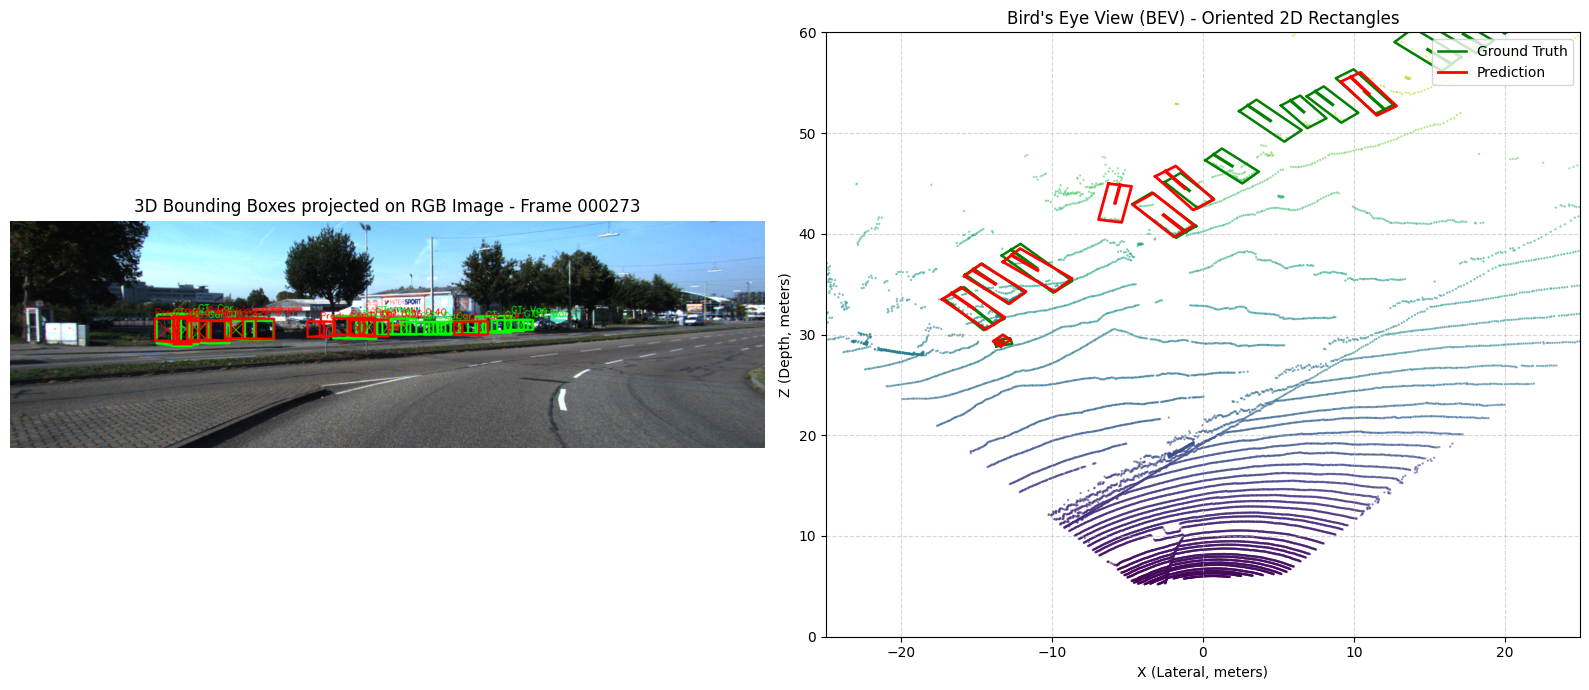

<Figure size 640x480 with 0 Axes>


🖼️ Frame #000613 | Classi uniche: 2 | Oggetti Totali: 12 | Distanti (>30m): 12


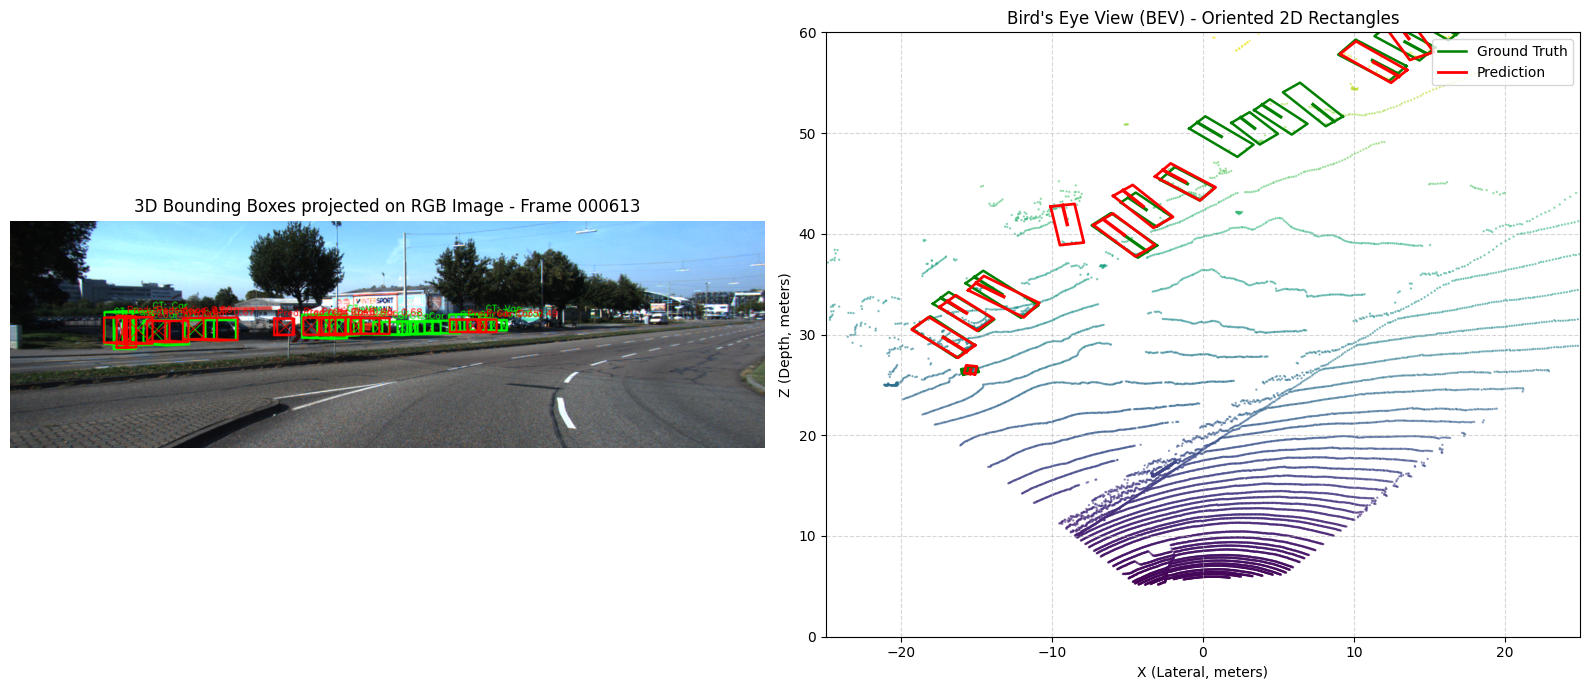

<Figure size 640x480 with 0 Axes>


🖼️ Frame #000201 | Classi uniche: 3 | Oggetti Totali: 12 | Distanti (>30m): 5


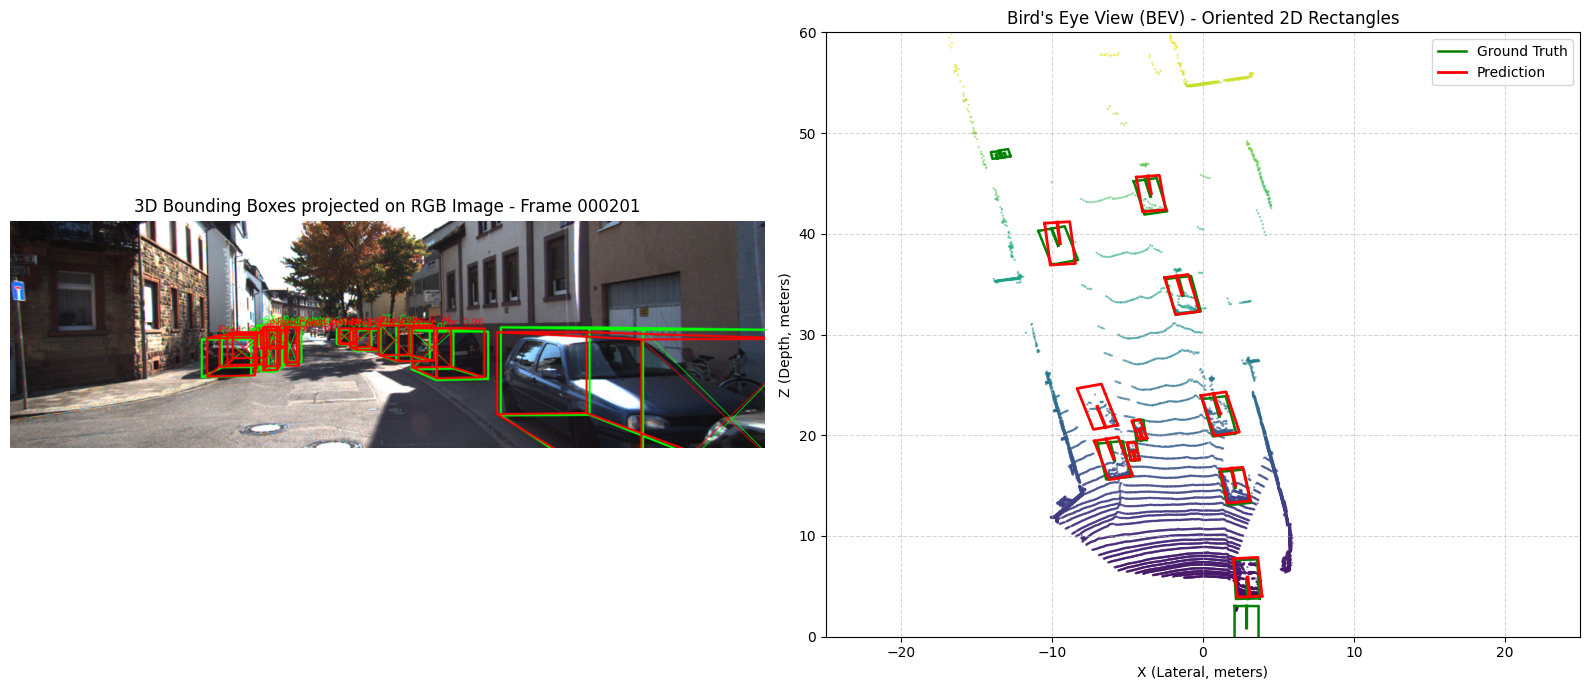

<Figure size 640x480 with 0 Axes>

In [22]:
import sys

sys.path.insert(0, "/content/3D_Perception")
from scripts.sample_visualizer import SampleVisualizer

# Inizializzazione
visualizer = SampleVisualizer(
    data_path="/content/drive/MyDrive/3D_Perception/data/kitti_validation"
)

# Visualizza i 3 frame più significativi
visualizer.visualize_experiment(
    exp_dir="/content/drive/MyDrive/3D_Perception/experiments/baseline_100perc",
    num_samples=3,
    conf_thresh=0.3,
)


🖼️ Frame #000273 | Classi uniche: 2 | Oggetti Totali: 12 | Distanti (>30m): 13


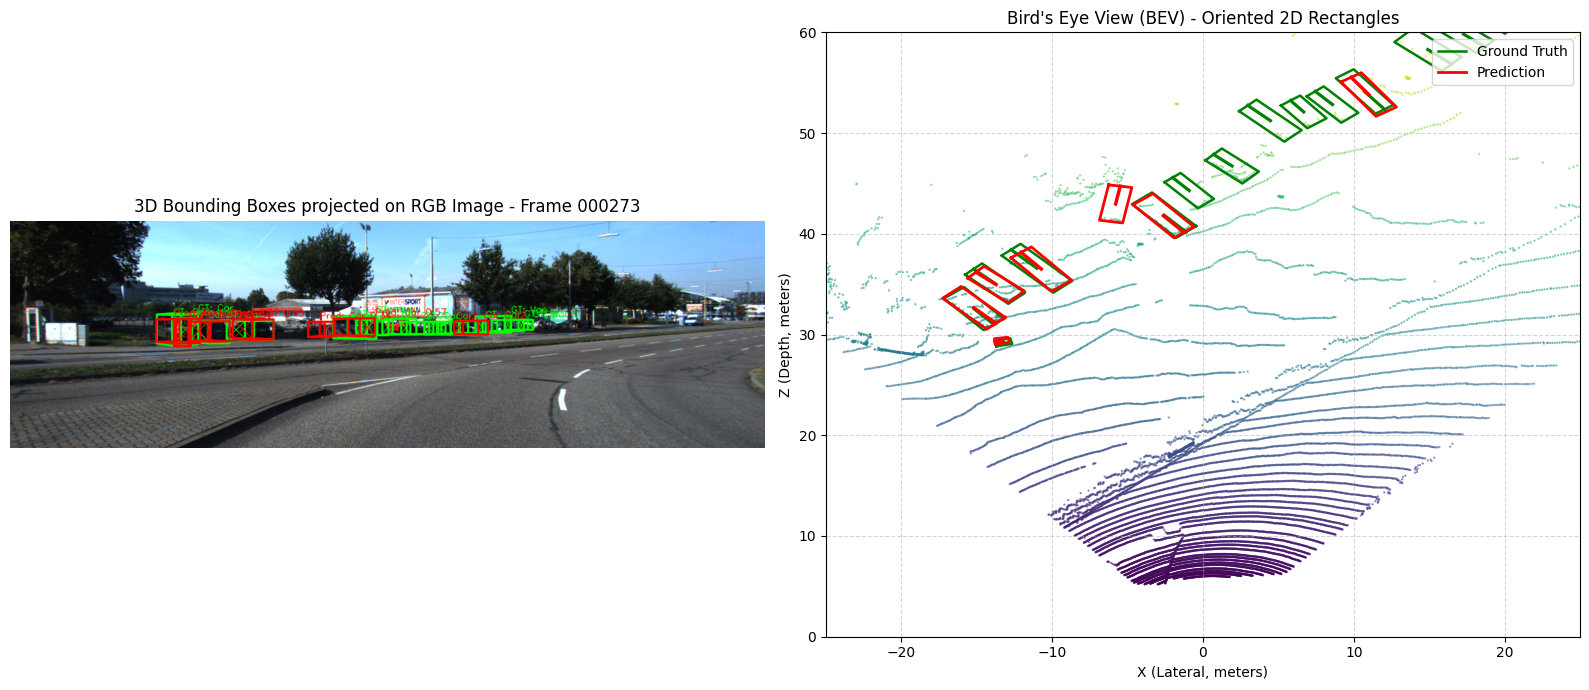

<Figure size 640x480 with 0 Axes>


🖼️ Frame #000613 | Classi uniche: 2 | Oggetti Totali: 12 | Distanti (>30m): 12


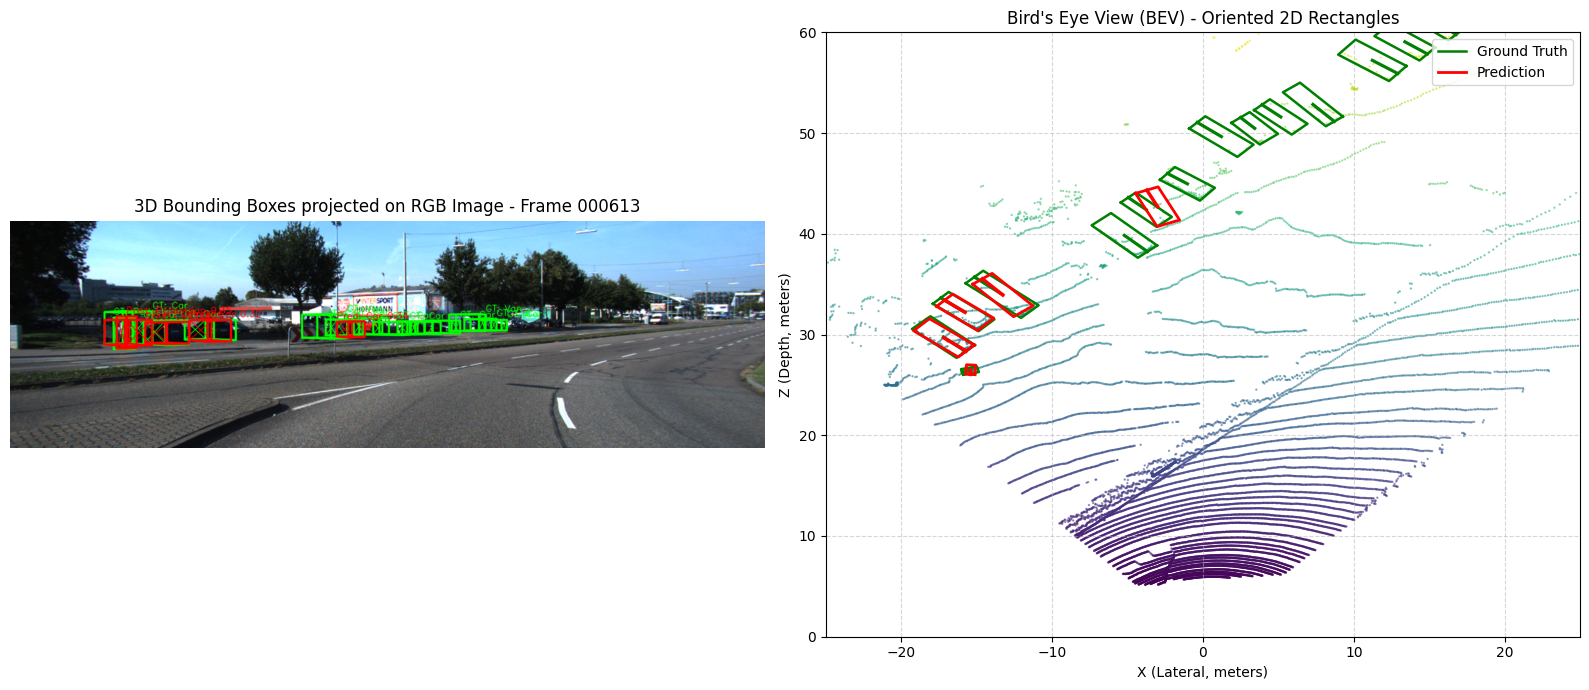

<Figure size 640x480 with 0 Axes>


🖼️ Frame #000201 | Classi uniche: 3 | Oggetti Totali: 12 | Distanti (>30m): 5


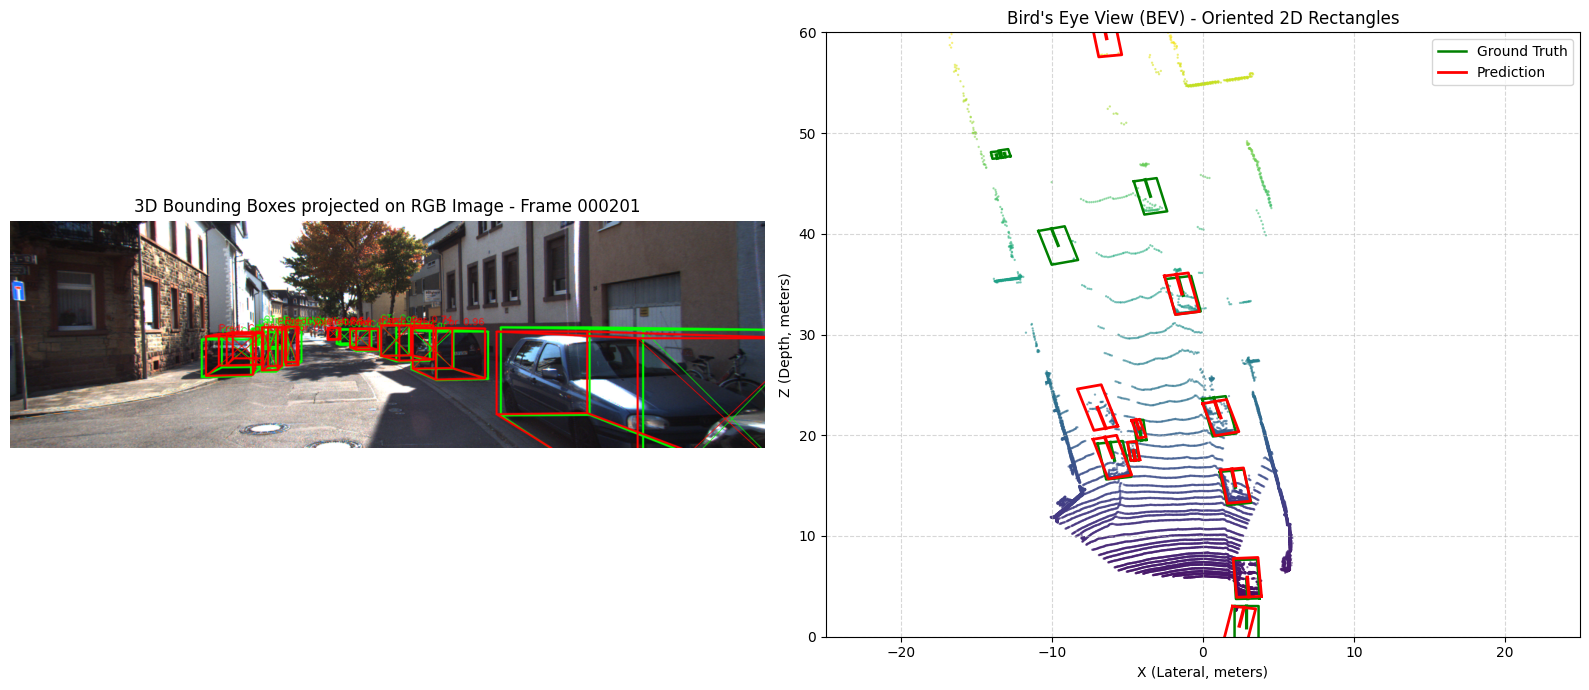

<Figure size 640x480 with 0 Axes>

In [23]:
import sys

sys.path.insert(0, "/content/3D_Perception")
from scripts.sample_visualizer import SampleVisualizer

# Inizializzazione
visualizer = SampleVisualizer(
    data_path="/content/drive/MyDrive/3D_Perception/data/kitti_validation"
)

# Visualizza i 3 frame più significativi
visualizer.visualize_experiment(
    exp_dir="/content/drive/MyDrive/3D_Perception/experiments/random_50perc",
    num_samples=3,
    conf_thresh=0.3,
)

In [7]:
!pip install numpy shapely

!python evaluate.py \
    --exp_dir "/content/drive/MyDrive/3D_Perception/experiments/baseline_100perc"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 129.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 119.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shapely]m1/2 [shapely]

 📊 RISULTATI mAP40 3D DETECTION (Python / Shapely)
Class        | Easy       | Moderate   | Hard      
-------------------------------------------------------
Car          |  67.84%    |  62.79%    |  58.33%    | 
Pedestrian   |  56.60%    |  52.08%    |  46.53%    | 
Cyclist      |  44.73%    |  44.24%    |  43.17%    | 

✅ Report salvato in: /content/drive/MyDrive/3D_Perception/experiments/baseline_100perc/map40_results.json


In [40]:
import json
import os

results_path = "/content/drive/MyDrive/3D_Perception/experiments/baseline_100perc/map40_results.json"

if os.path.exists(results_path):
    with open(results_path, "r") as f:
        data = json.load(f)
    print("\n📋 RIEPILOGO JSON:")
    print(json.dumps(data, indent=4))
else:
    print("⚠️ File risultati non trovato. Verificare l'esito della Cella 3.")


📋 RIEPILOGO JSON:
{
    "Car": {
        "Easy": 64.4433075318964,
        "Moderate": 61.640460925463415,
        "Hard": 57.38004511588319
    },
    "Pedestrian": {
        "Easy": 54.216056186999225,
        "Moderate": 50.889539301085115,
        "Hard": 44.33532999498112
    },
    "Cyclist": {
        "Easy": 53.256655621497586,
        "Moderate": 45.52910757521412,
        "Hard": 44.72490359602641
    }
}


In [41]:
import os
import glob
import numpy as np
from evaluate import load_kitti_txt, compute_iou_3d

exp_dir = "/content/drive/MyDrive/3D_Perception/experiments/baseline_100perc"
gt_files = sorted(glob.glob(os.path.join(exp_dir, "gt_labels/*.txt")))

car_ious = []
num_gt_cars, num_pred_cars = 0, 0

for gt_path in gt_files:
    fname = os.path.basename(gt_path)
    pred_path = os.path.join(exp_dir, "pred_labels", fname)

    gt = load_kitti_txt(gt_path, is_pred=False)
    pred = load_kitti_txt(pred_path, is_pred=True)

    if gt is None or pred is None:
        continue

    gt_m = (gt['name'] == 'Car')
    pred_m = (pred['name'] == 'Car')
    num_gt_cars += np.sum(gt_m)
    num_pred_cars += np.sum(pred_m)

    for g_loc, g_dim, g_ry in zip(gt['location'][gt_m], gt['dimensions'][gt_m], gt['rotation_y'][gt_m]):
        for p_loc, p_dim, p_ry in zip(pred['location'][pred_m], pred['dimensions'][pred_m], pred['rotation_y'][pred_m]):
            iou = compute_iou_3d(g_loc, g_dim, g_ry, p_loc, p_dim, p_ry)
            if iou > 0.05:
                car_ious.append(iou)

print("=" * 60)
print(f"📊 DIAGNOSTICA ISPEZIONE CLASSE 'CAR':")
print(f"  • Oggetti GT 'Car' totali:     {num_gt_cars}")
print(f"  • Predizioni 'Car' totali:     {num_pred_cars}")
if car_ious:
    print(f"  • IoU Massimo registrato:       {max(car_ious):.4f}")
    print(f"  • IoU Medio (sopra 0.05):       {np.mean(car_ious):.4f}")
    print(f"  • Coppie con IoU >= 0.50:       {sum(1 for i in car_ious if i >= 0.50)}")
    print(f"  • Coppie con IoU >= 0.70 (OK):  {sum(1 for i in car_ious if i >= 0.70)}")
else:
    print("  ⚠️ Nessuna sovrapposizione IoU > 0.05 trovata per la classe Car.")
print("=" * 60)

📊 DIAGNOSTICA ISPEZIONE CLASSE 'CAR':
  • Oggetti GT 'Car' totali:     1094
  • Predizioni 'Car' totali:     1295
  • IoU Massimo registrato:       0.9540
  • IoU Medio (sopra 0.05):       0.6748
  • Coppie con IoU >= 0.50:       933
  • Coppie con IoU >= 0.70 (OK):  683


In [54]:
%%writefile /content/visualize_debug.py
import sys
import os
import cv2
import numpy as np

# Setta il backend non interattivo PRIMA di qualsiasi import di matplotlib.pyplot
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

sys.path.insert(0, "/content/3D_Perception")

from src import KittiDataset, LidarDetector, Visualizer

data_path = "/content/drive/MyDrive/3D_Perception/data/kitti_validation"
dataset = KittiDataset(data_root=data_path)
detector = LidarDetector(conf_threshold=0.3)

# Cerca il primo frame che contiene auto in GT
sample_idx = 4
# for idx in range(len(dataset)):
#     gt_boxes = dataset[idx].get('gt_boxes', dataset[idx].get('labels', []))
#     if any(obj['type'] == 'Car' for obj in gt_boxes):
#         sample_idx = idx
#         break

sample = dataset[sample_idx]
sample['labels'] = sample.get('gt_boxes', sample.get('labels', []))

# Gestione della chiave 'image'
if 'image' not in sample:
    img_path = sample.get('image_path') or sample.get('img_path')
    if img_path and os.path.exists(img_path):
        img_bgr = cv2.imread(img_path)
        sample['image'] = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    else:
        sample['image'] = np.zeros((375, 1242, 3), dtype=np.uint8)

# Inferenza
predictions = detector.detect(sample)

# Test correzione Yaw (-90 gradi / -pi/2 rad) sulle predizioni Car
# for pred in predictions:
#     if pred.type == 'Car':
#         new_ry = pred.rotation_y - (np.pi / 2.0)
#         pred.rotation_y = float((new_ry + np.pi) % (2 * np.pi) - np.pi)

# Generazione della scena e salvataggio
Visualizer.visualize_scene(sample, predictions, draw_gt=True)
plt.savefig("/content/debug_bev.png", bbox_inches='tight', dpi=150)
print(f"✅ Grafico salvato con successo per il frame #{sample_idx} in /content/debug_bev.png")

Overwriting /content/visualize_debug.py


In [55]:
!/usr/local/miniconda/envs/openmmlab/bin/python /content/visualize_debug.py

⚡ Caricamento PointPillars su cuda:0
/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/mmdet3d/models/dense_heads/anchor3d_head.py:94: UserWarning: dir_offset and dir_limit_offset will be depressed and be incorporated into box coder in the future
  warnings.warn(
Loads checkpoint by local backend from path: /content/3D_Perception/weights/pointpillar_kitti.pth
🏷️ Mapping classi rilevato dal modello: ['Pedestrian', 'Cyclist', 'Car']
/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
✅ Grafico salvato con successo per il frame #4 in /content/debug_bev.png


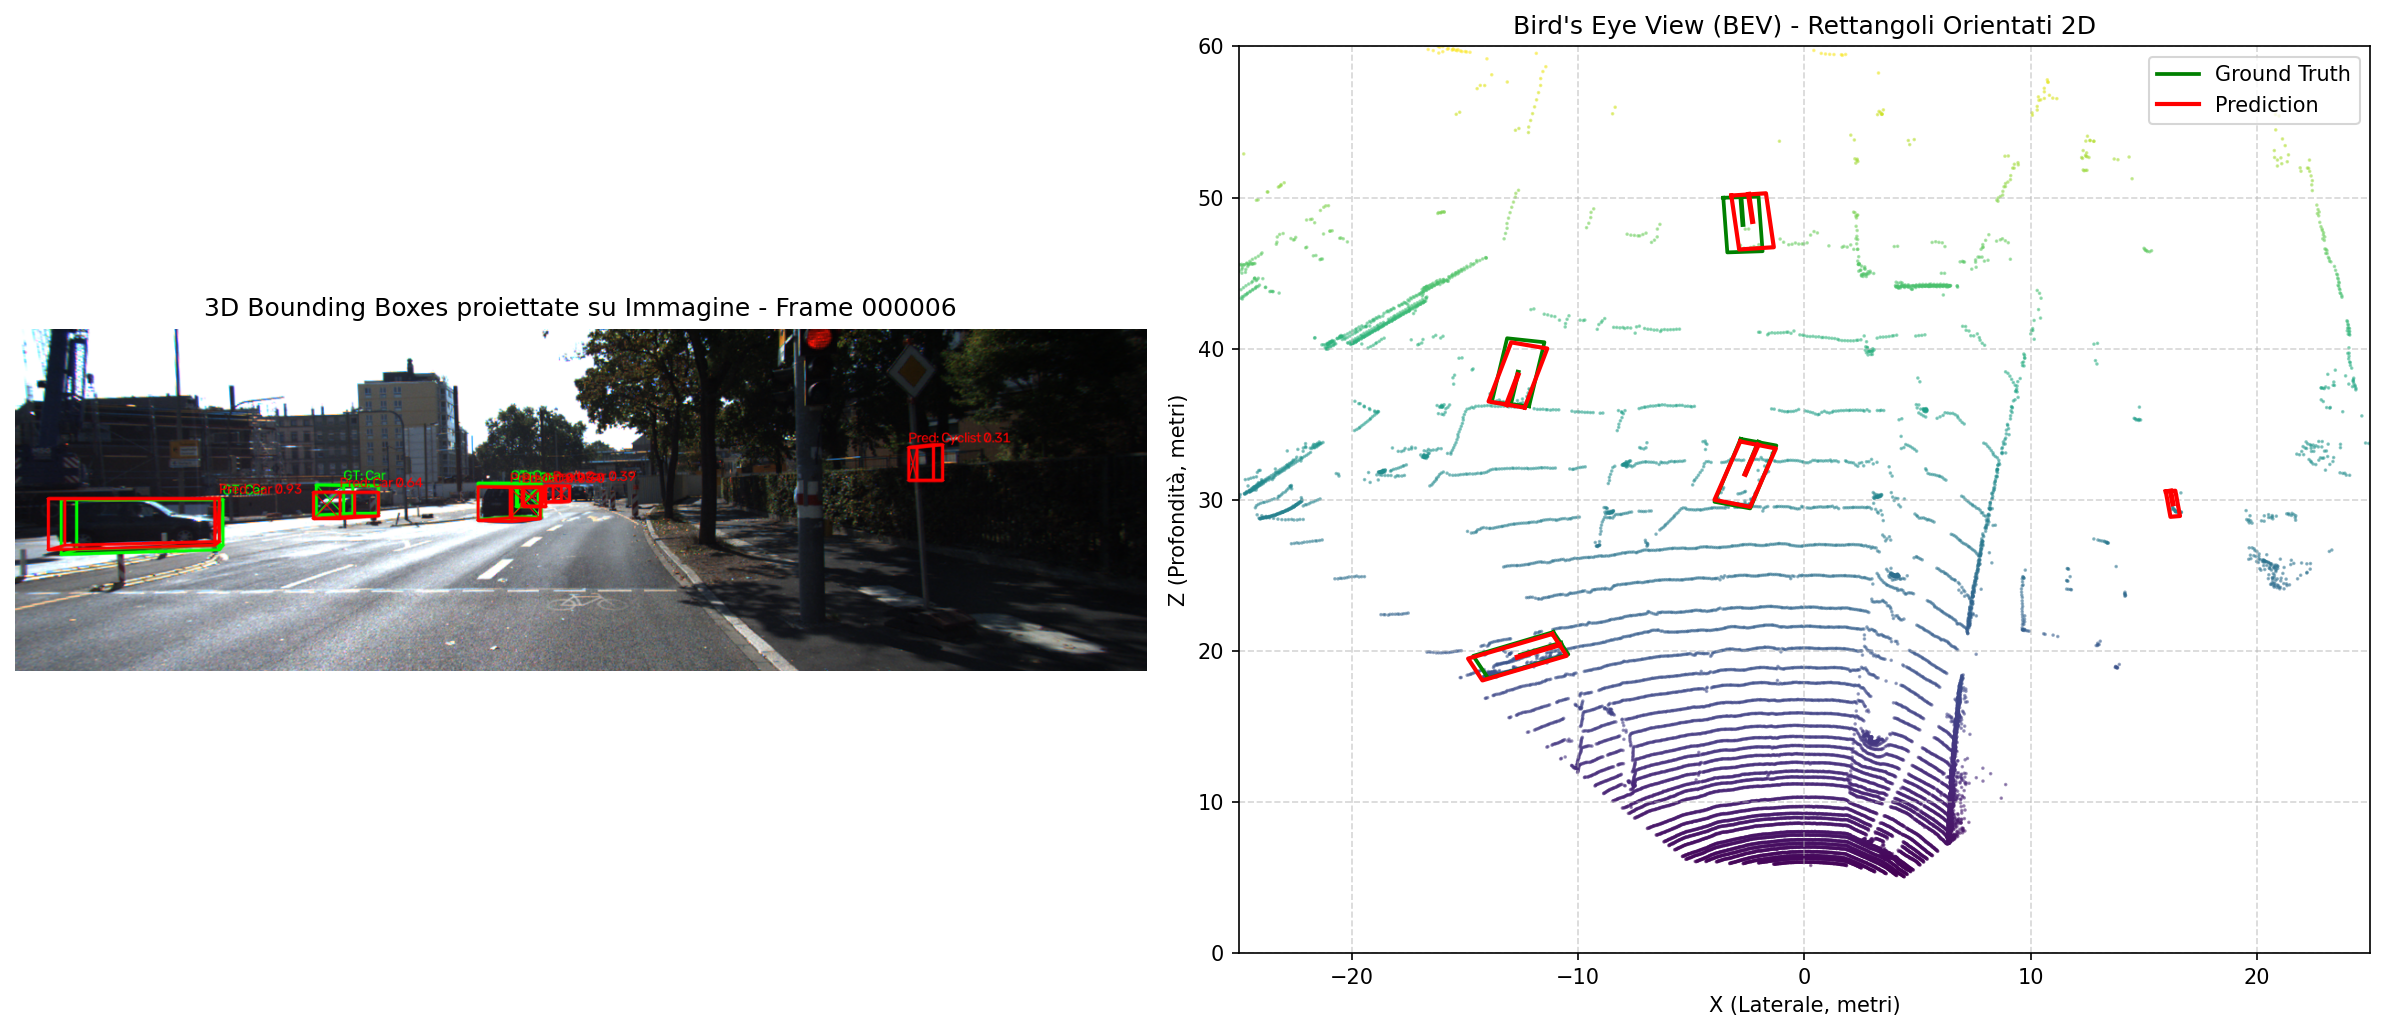

In [56]:
from IPython.display import Image
Image('/content/debug_bev.png')

In [ ]:
%%bash
source /usr/local/miniconda/bin/activate openmmlab

cd /content/3D_Perception
git pull

python validate_lidar.py --subsample_mode random --subsample_ratio 0.5 --max_samples 300

Already up to date.
⚡ Caricamento PointPillars su cuda:0
Loads checkpoint by local backend from path: /content/3D_Perception/weights/pointpillar_kitti.pth
🏷️ Mapping classi rilevato dal modello: ['Pedestrian', 'Cyclist', 'Car']

📊 Avvio Inferenza PointPillars [RANDOM_50PERC] | Campioni: 300/2259
💾 Destinazione file .txt su Drive: /content/drive/MyDrive/3D_Perception/experiments/random_50perc

✅ Inferenza e salvataggio completati con successo!
  • Predizioni salvate in: /content/drive/MyDrive/3D_Perception/experiments/random_50perc/pred_labels
  • Ground Truth salvate in: /content/drive/MyDrive/3D_Perception/experiments/random_50perc/gt_labels


/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/mmdet3d/models/dense_heads/anchor3d_head.py:94: UserWarning: dir_offset and dir_limit_offset will be depressed and be incorporated into box coder in the future
  warnings.warn(
Elaborazione Frame:   0%|          | 0/300 [00:00<?, ?it/s]/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Elaborazione Frame: 100%|██████████| 300/300 [00:18<00:00, 16.01it/s]


In [46]:
!python evaluate.py \
    --exp_dir "/content/drive/MyDrive/3D_Perception/experiments/random_50perc"


 📊 RISULTATI mAP40 3D DETECTION (Python / Shapely)
Class        | Easy       | Moderate   | Hard      
-------------------------------------------------------
Car          |  64.60%    |  54.30%    |  49.64%    | 
Pedestrian   |  55.08%    |  50.68%    |  42.89%    | 
Cyclist      |  53.03%    |  36.35%    |  36.66%    | 

✅ Report salvato in: /content/drive/MyDrive/3D_Perception/experiments/random_50perc/map40_results.json


In [47]:
import json
import os

results_path = "/content/drive/MyDrive/3D_Perception/experiments/random_50perc/map40_results.json"

if os.path.exists(results_path):
    with open(results_path, "r") as f:
        data = json.load(f)
    print("\n📋 RIEPILOGO JSON:")
    print(json.dumps(data, indent=4))
else:
    print("⚠️ File risultati non trovato. Verificare l'esito della Cella 3.")


📋 RIEPILOGO JSON:
{
    "Car": {
        "Easy": 64.60459895296553,
        "Moderate": 54.30291617250151,
        "Hard": 49.64204876803991
    },
    "Pedestrian": {
        "Easy": 55.08058102277224,
        "Moderate": 50.676959482640484,
        "Hard": 42.89066532736453
    },
    "Cyclist": {
        "Easy": 53.03066743938955,
        "Moderate": 36.34650361470849,
        "Hard": 36.65698768823768
    }
}


In [ ]:
%%bash
source /usr/local/miniconda/bin/activate openmmlab

cd /content/3D_Perception
git pull

python validate_lidar.py --subsample_mode random --subsample_ratio 0.25 --max_samples 300

Already up to date.
⚡ Caricamento PointPillars su cuda:0
Loads checkpoint by local backend from path: /content/3D_Perception/weights/pointpillar_kitti.pth
🏷️ Mapping classi rilevato dal modello: ['Pedestrian', 'Cyclist', 'Car']

📊 Avvio Inferenza PointPillars [RANDOM_25PERC] | Campioni: 300/2259
💾 Destinazione file .txt su Drive: /content/drive/MyDrive/3D_Perception/experiments/random_25perc

✅ Inferenza e salvataggio completati con successo!
  • Predizioni salvate in: /content/drive/MyDrive/3D_Perception/experiments/random_25perc/pred_labels
  • Ground Truth salvate in: /content/drive/MyDrive/3D_Perception/experiments/random_25perc/gt_labels


/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/mmdet3d/models/dense_heads/anchor3d_head.py:94: UserWarning: dir_offset and dir_limit_offset will be depressed and be incorporated into box coder in the future
  warnings.warn(
Elaborazione Frame:   0%|          | 0/300 [00:00<?, ?it/s]/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Elaborazione Frame: 100%|██████████| 300/300 [00:18<00:00, 16.04it/s]


In [49]:
!python evaluate.py \
    --exp_dir "/content/drive/MyDrive/3D_Perception/experiments/random_25perc"


 📊 RISULTATI mAP40 3D DETECTION (Python / Shapely)
Class        | Easy       | Moderate   | Hard      
-------------------------------------------------------
Car          |  50.88%    |  41.36%    |  35.68%    | 
Pedestrian   |  40.16%    |  36.22%    |  31.57%    | 
Cyclist      |  23.46%    |  17.21%    |  18.49%    | 

✅ Report salvato in: /content/drive/MyDrive/3D_Perception/experiments/random_25perc/map40_results.json


In [50]:
import json
import os

results_path = "/content/drive/MyDrive/3D_Perception/experiments/random_25perc/map40_results.json"

if os.path.exists(results_path):
    with open(results_path, "r") as f:
        data = json.load(f)
    print("\n📋 RIEPILOGO JSON:")
    print(json.dumps(data, indent=4))
else:
    print("⚠️ File risultati non trovato. Verificare l'esito della Cella 3.")


📋 RIEPILOGO JSON:
{
    "Car": {
        "Easy": 50.88345947536047,
        "Moderate": 41.35614392471886,
        "Hard": 35.68147151169966
    },
    "Pedestrian": {
        "Easy": 40.157848041129455,
        "Moderate": 36.218305597875904,
        "Hard": 31.574785620084167
    },
    "Cyclist": {
        "Easy": 23.455660167035376,
        "Moderate": 17.209595959595955,
        "Hard": 18.49409981658106
    }
}
